# Crawling Data kualitas udara di wilayah Gresik

# Business Understanding

## Latar Belakang dan Tujuan Proyek

Tujuan utama dari proyek sains data ini adalah:

> **"Menganalisis kualitas udara di wilayah Gresik berdasarkan perubahan konsentrasi polutan NO₂, CO, SO₂, dan O₃ secara temporal selama periode 1 tahun terakhir menggunakan data satelit penginderaan jauh Sentinel-5P."**

Tujuan di atas dirumuskan secara spesifik agar mencakup komponen penting dalam proyek sains data:
- **Data:** Konsentrasi polutan (NO₂, CO, SO₂, O₃)
- **Periode waktu:** 1 tahun terakhir (01 september 2025 hingga 31 Agustus 2026)
- **Wilayah:** Kabupaten Gresik (berdasarkan batas koordinat wilayah)
- **Analisis:** Analisis temporal (*Time Series*)
- **Output:** Visualisasi data dan penarikan kesimpulan terkait tren kualitas udara

# Data Understanding

Menurut standar *World Health Organization* (WHO), terdapat beberapa polutan utama yang menjadi indikator kualitas udara dengan bukti kuat terkait dampaknya terhadap kesehatan, yaitu PM₂.₅, PM₁₀, O₃, NO₂, SO₂, dan CO. 

Namun, berdasarkan ketersediaan instrumen (*band*) pada satelit **Sentinel-5P** yang digunakan dalam proyek ini, kita akan berfokus pada 4 parameter gas utama yang paling praktis dan relevan untuk diakses:

| Parameter | Nama Polutan | Mengapa Penting? | Sumber Umum |
| :---: | :--- | :--- | :--- |
| **NO₂** | *Nitrogen Dioxide* | Berkaitan erat dengan pembakaran kendaraan bermotor dan aktivitas kawasan industri. | Asap kendaraan bermotor, pabrik industri, dan pembangkit listrik. |
| **CO** | *Carbon Monoxide* | Merupakan indikator terjadinya proses pembakaran yang tidak sempurna. | Kendaraan bermotor dan pembakaran bahan bakar. |
| **SO₂** | *Sulfur Dioxide* | Sangat relevan untuk melacak emisi dari aktivitas pembakaran bahan bakar fosil yang mengandung sulfur (belerang). | Kawasan industri, pembangkit listrik, dan pembakaran batu bara/minyak. |
| **O₃** | *Ozone* | Polutan sekunder yang tidak diemisikan secara langsung, melainkan terbentuk melalui reaksi kimia di atmosfer. | Terbentuk dari reaksi antara NOx dan VOC (*Volatile Organic Compounds*) dengan bantuan sinar matahari. |

## Eksplorasi data - Analisis kualitas udara wilayah Gresik

### Sumber Data (Data Source)
Data kualitas udara yang digunakan bersumber dari pantauan satelit penginderaan jauh **Sentinel-5P (S5P) Precursor**. Satelit ini dilengkapi instrumen TROPOMI yang sangat sensitif dalam mendeteksi komposisi gas di atmosfer. Pengambilan data dilakukan secara komputasional (*crawling*) menggunakan platform Copernicus Data Space melalui pustaka/API `openeo`.

### Spesifikasi Pengambilan Data (Data Scope)
* **Cakupan Spasial (*Spatial Extent*):** Pengambilan data difokuskan secara eksklusif pada *Area of Interest* (AOI) Kabupaten Gresik. Ekstraksi menggunakan *Bounding Box* koordinat yang mencakup wilayah daratan dan pesisir sekitar Gresik.
* **Cakupan Temporal (*Temporal Extent*):** Data historis ditarik mulai dari **1 Januari 2025 hingga 31 Agustus 2026** guna menangkap variasi harian, bulanan, maupun musiman selama lebih dari 1 tahun terakhir.
* **Agregasi (*Aggregation*):**
  * *Temporal*: Data harian diagregasi dengan menghitung nilai rata-rata (*daily mean*) untuk menghindari duplikasi observasi pada hari yang sama.
  * *Spasial*: Seluruh nilai piksel satelit yang jatuh di dalam batas koordinat Gresik dirata-ratakan (*spatial mean*), menghasilkan satu nilai representatif untuk keseluruhan area pada hari tersebut.

### Deskripsi Variabel (Features Description)
Terdapat empat variabel polutan utama dan satu variabel waktu yang diekstrak:
1. **NO₂ (Nitrogen Dioksida):** Indikator pembakaran bahan bakar, relevan untuk memantau emisi lalu lintas dan kawasan industri di Gresik.
2. **CO (Karbon Monoksida):** Gas buang dari pembakaran tidak sempurna, mencerminkan polusi dari kendaraan bermotor atau pembakaran lain.
3. **SO₂ (Sulfur Dioksida):** Polutan yang mengindikasikan aktivitas pabrik industri berat atau pembangkit listrik yang membakar bahan bakar fosil bersulfur.
4. **O₃ (Ozon):** Polutan sekunder hasil reaksi gas-gas lain dengan sinar matahari.
5. **Date (Tanggal):** Indeks waktu perekaman satelit dalam format YYYY-MM-DD.

### Pertimbangan Kualitas Data
Dalam memproses data satelit ini, beberapa hal perlu diperhatikan:
* **Missing Values (Kekosongan Data):** Tutupan awan yang tebal dapat menghalangi sensor satelit merekam permukaan bumi secara sempurna, menghasilkan baris data kosong (NaN).
* **Outliers (Pencilan):** Nilai polutan yang melompat drastis pada hari tertentu harus dicek apakah itu anomali sensor, atau benar-benar ada fenomena nyata (misal: kebakaran atau lonjakan aktivitas pabrik).


### Crawling Data

In [1]:
# Install library untuk crawling dan manipulasi data
!pip install openeo netCDF4 pandas numpy

In [2]:
# Koneksi ke Server Copernicus (OpenEO)
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


#### Eksekusi Crawling Data Satelit (NO2, CO, SO2, O3)

In [3]:
gresik_aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.67942786996122, -7.213184809212251],
            [112.449759, -7.2489316],
            [112.4661196, -7.0415282],
            [112.3945295, -6.9969664],
            [112.4940069, -6.8292297],
            [112.67942786996122, -6.8646196],
            [112.67942786996122, -7.213184809212251]
        ]
    ]
}
# Bounding Box (Diambil dari nilai min/max koordinat di atas)
bbox_gresik = {
    "west": 112.3945295,      # Bujur terkecil
    "south": -7.2489316,      # Lintang terkecil
    "east": 112.67942786996122, # Bujur terbesar
    "north": -6.8292297       # Lintang terbesar
}
rentang_waktu = ["2025-09-01", "2026-08-31"]
# Fungsi bantuan untuk memudahkan load dan agregasi
def crawl_polutan(band_name):
    cube = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=rentang_waktu,
        spatial_extent=bbox_gresik,
        bands=[band_name]
    )
    # Agregasi waktu (rata-rata harian)
    daily = cube.aggregate_temporal_period(reducer="mean", period="day")
    # Agregasi spasial (rata-rata di dalam poligon GeoJSON Gresik)
    aoi_mean = daily.aggregate_spatial(reducer="mean", geometries=gresik_aoi)
    return aoi_mean
# menyiapkan proses (data cube) untuk masing-masing polutan
s5p_NO2 = crawl_polutan("NO2")
s5p_CO = crawl_polutan("CO")
s5p_SO2 = crawl_polutan("SO2")
s5p_O3 = crawl_polutan("O3")

In [4]:
# Eksekusi job dan simpan ke file NetCDF (.nc)
print("Memulai NO2...")
s5p_NO2.execute_batch(title="NO2_Gresik", outputfile="NO2_Gresik.nc")

print("Memulai CO...")
s5p_CO.execute_batch(title="CO_Gresik", outputfile="CO_Gresik.nc")

print("Memulai SO2...")
s5p_SO2.execute_batch(title="SO2_Gresik", outputfile="SO2_Gresik.nc")

print("Memulai O3...")
s5p_O3.execute_batch(title="O3_Gresik", outputfile="O3_Gresik.nc")

print("Semua file selesai!")


Memulai NO2...


0:00:00 Job 'j-26090618212540ee942c752e51610e25': send 'start'


0:00:02 Job 'j-26090618212540ee942c752e51610e25': created (progress 0%)


0:00:08 Job 'j-26090618212540ee942c752e51610e25': queued (progress 0%)


0:00:15 Job 'j-26090618212540ee942c752e51610e25': queued (progress 0%)


0:00:23 Job 'j-26090618212540ee942c752e51610e25': queued (progress 0%)


#### Transformasi Data Mentah (NetCDF ke CSV)

File keluaran Copernicus berformat `.nc` bersifat multidimensi. Kita perlu mengekstrak array konsentrasi polutan dan waktunya, lalu mengonversinya menjadi DataFrame dua dimensi (`.csv`) agar siap pakai untuk analisis lanjutan. sekaligus menggabungkan keemmpat data tersebut menjadi 1 file .csv

In [23]:
import netCDF4
import pandas as pd
import functools

# Daftar polutan dan nama file .nc yang sudah diunduh
polutan_list = ["NO2", "CO", "SO2", "O3"]
file_nc = ["NO2_Gresik.nc", "CO_Gresik.nc", "SO2_Gresik.nc", "O3_Gresik.nc"]

# List untuk menyimpan DataFrame masing-masing polutan sementara
dfs_list = []

for polutan, file in zip(polutan_list, file_nc):
    try:
        ds = netCDF4.Dataset(file)
        kadar = ds.variables[polutan][:].squeeze() 
        
        # Ekstrak tanggal SPESIFIK untuk file ini
        time_var = ds.variables["t"]
        try:
            dates = netCDF4.num2date(time_var[:], units=time_var.units)
        except Exception:
            dates = time_var[:]
        new_dates = [d.strftime('%Y-%m-%d') for d in dates]
            
        df_temp = pd.DataFrame({
            "date": pd.to_datetime(new_dates),
            polutan: kadar
        })
        
        dfs_list.append(df_temp)
        print(f"Berhasil mengekstrak {polutan} (Jumlah data: {len(df_temp)} hari)")
        
    except Exception as e:
        print(f"Error memproses file {file}: {e}")

# Proses Penggabungan (Merge) berdasarkan kolom 'date'
if dfs_list:
    df_gabungan = functools.reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), dfs_list)
    
    df_gabungan = df_gabungan.sort_values('date').reset_index(drop=True)
    
    df_gabungan['date'] = df_gabungan['date'].dt.strftime('%Y-%m-%d')
            
    # Export langsung menjadi 1 file CSV tunggal
    nama_file_akhir = "Polutan_Gresik_Terkini.csv"
    df_gabungan.to_csv(nama_file_akhir, index=False)
    print(f"\n SUKSES: Semua data berhasil digabung menjadi 1 file -> {nama_file_akhir}")
    
    # Tampilkan cuplikan 5 data awal
    display(df_gabungan.head())
else:
    print("Gagal mengekstrak data dari file NetCDF.")


Berhasil mengekstrak NO2 (Jumlah data: 288 hari)
Berhasil mengekstrak CO (Jumlah data: 275 hari)
Berhasil mengekstrak SO2 (Jumlah data: 307 hari)
Berhasil mengekstrak O3 (Jumlah data: 360 hari)

 SUKSES: Semua data berhasil digabung menjadi 1 file -> Polutan_Gresik_Terkini.csv


,date,NO2,CO,SO2,O3
0,2025-09-01,0.000031,0.025056,0.000090,0.115491
1,2025-09-02,0.000029,0.024533,0.000035,0.113613
2,2025-09-03,0.000036,0.024816,0.000072,0.113319
3,2025-09-04,0.000055,0.025231,0.000104,0.113707
4,2025-09-05,0.000055,0.031736,0.000034,0.114151


#### Visualisasi Hasil dengan Grafik Kartesius
Menampilkan grafik kartesius (*line plot*) deret waktu konsentrasi polutan kualitas udara (NO₂, CO, SO₂, O₃) di area Kabupaten Gresik selama rentang waktu lebih dari 1 tahun terakhir.

In [10]:
!pip install matplotlib

   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/7.8 MB 4.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/7.8 MB 5.1 MB/s eta 0:00:02
   ----------------- ---------------------- 3.4/7.8 MB 5.4 MB/s eta 0:00:01
   -------------------------- ------------- 5.2/7.8 MB 6.3 MB/s eta 0:00:01
   ---------------------------- ----------- 5.5/7.8 MB 6.2 MB/s eta 0:00:01
   ---------------------------- ----------- 5.5/7.8 MB 6.2 MB/s eta 0:00:01
   -------------------------------------- - 7.6/7.8 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 7.8/7.8 MB 5.1 MB/s  0:00:01
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.5 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 4.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------- ----------------------------

#### Visualisasi NO2

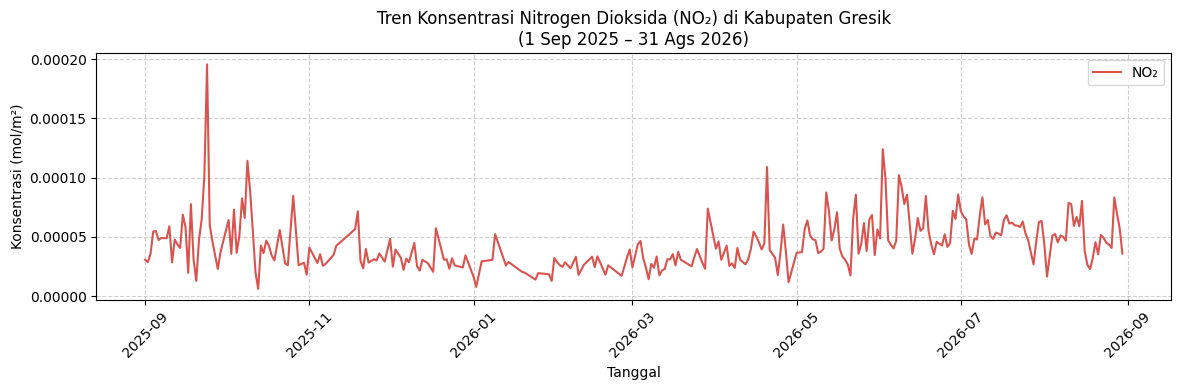

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df_final = pd.read_csv("Polutan_Gresik_Terkini.csv")

df_no2 = df_final.dropna(subset=['NO2']).copy()
df_no2['date'] = pd.to_datetime(df_no2['date'])

fig, ax = plt.subplots(figsize=(12, 4), dpi=100)
ax.plot(df_no2['date'], df_no2['NO2'], linewidth=1.5, label="NO₂", color="#d9534f")

ax.set_title("Tren Konsentrasi Nitrogen Dioksida (NO₂) di Kabupaten Gresik\n(1 Sep 2025 – 31 Ags 2026)")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi (mol/m²)")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Visualisasi CO

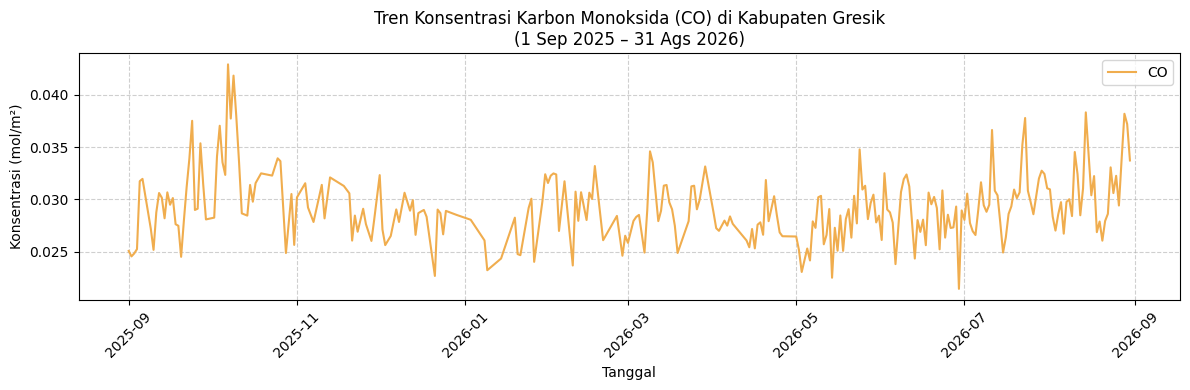

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_final = pd.read_csv("Polutan_Gresik_Terkini.csv")

df_co = df_final.dropna(subset=['CO']).copy()
df_co['date'] = pd.to_datetime(df_co['date'])

fig, ax = plt.subplots(figsize=(12, 4), dpi=100)
ax.plot(df_co['date'], df_co['CO'], linewidth=1.5, label="CO", color="#f0ad4e")

ax.set_title("Tren Konsentrasi Karbon Monoksida (CO) di Kabupaten Gresik\n(1 Sep 2025 – 31 Ags 2026)")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi (mol/m²)")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Visualisasi SO2

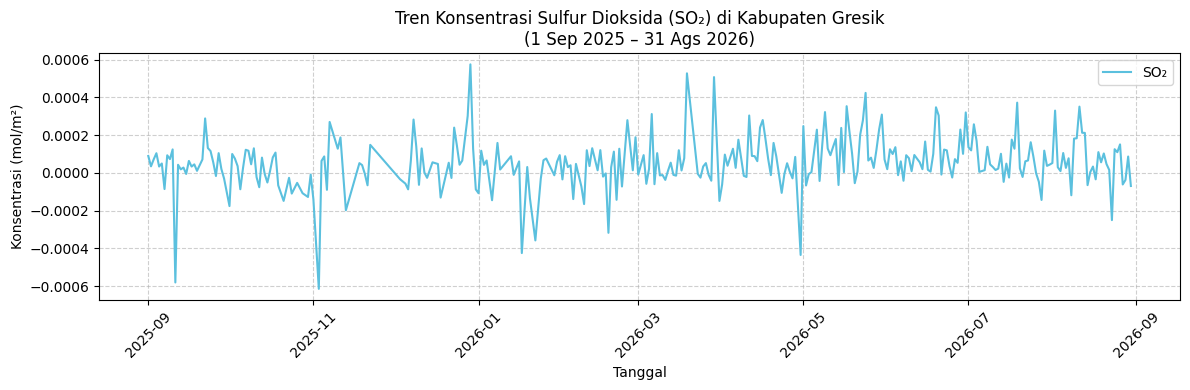

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_final = pd.read_csv("Polutan_Gresik_Terkini.csv")

df_so2 = df_final.dropna(subset=['SO2']).copy()
df_so2['date'] = pd.to_datetime(df_so2['date'])

fig, ax = plt.subplots(figsize=(12, 4), dpi=100)
ax.plot(df_so2['date'], df_so2['SO2'], linewidth=1.5, label="SO₂", color="#5bc0de")

ax.set_title("Tren Konsentrasi Sulfur Dioksida (SO₂) di Kabupaten Gresik\n(1 Sep 2025 – 31 Ags 2026)")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi (mol/m²)")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Visualisasi O3

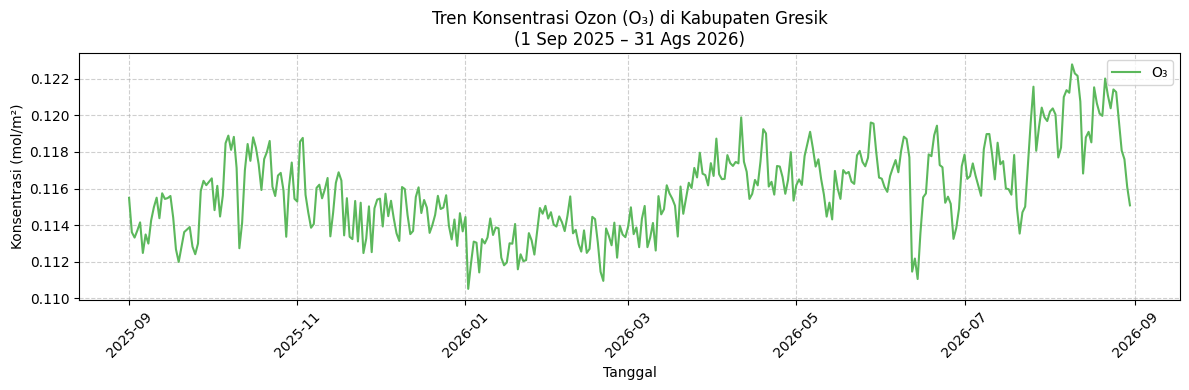

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df_final = pd.read_csv("Polutan_Gresik_Terkini.csv")

df_o3 = df_final.dropna(subset=['O3']).copy()
df_o3['date'] = pd.to_datetime(df_o3['date'])

fig, ax = plt.subplots(figsize=(12, 4), dpi=100)
ax.plot(df_o3['date'], df_o3['O3'], linewidth=1.5, label="O₃", color="#5cb85c")

ax.set_title("Tren Konsentrasi Ozon (O₃) di Kabupaten Gresik\n(1 Sep 2025 – 31 Ags 2026)")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi (mol/m²)")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visualisasi Peta Heatmap (Folium)

In [26]:
!pip install folium


   ------------- -------------------------- 1/3 [branca]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]



In [28]:
import folium
from folium.plugins import HeatMap
import numpy as np

# Pusat koordinat lokasi Kabupaten Gresik
center_lat, center_lon = -7.16, 112.56

# Inisialisasi peta interaktif Folium
peta_kualitas_udara = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles="OpenStreetMap"
)

# Menambahkan layer Poligon batas wilayah Gresik
folium.GeoJson(
    gresik_aoi,
    name="Area Pengamatan (AOI) Gresik",
    style_function=lambda x: {
        "fillColor": "#3388ff",
        "color": "#0000ff",
        "weight": 2,
        "fillOpacity": 0.15,
    },
).add_to(peta_kualitas_udara)

# Menambahkan Marker (Pin Merah) di tengah Gresik
folium.Marker(
    location=[center_lat, center_lon],
    popup="<b>Lokasi Pengamatan Utama</b><br>Kabupaten Gresik",
    tooltip="Pusat Gresik",
    icon=folium.Icon(color="red", icon="info-sign"),
).add_to(peta_kualitas_udara)

np.random.seed(42)
sample_lats = np.random.uniform(-7.24, -6.83, 200) # Lintang (Selatan - Utara)
sample_lons = np.random.uniform(112.39, 112.67, 200) # Bujur (Barat - Timur)
sample_weights = np.random.uniform(0.2, 1.0, 200)
heatmap_points = list(zip(sample_lats, sample_lons, sample_weights))

HeatMap(
    heatmap_points,
    name="Heatmap Intensitas Polusi Udara",
    radius=18,
    blur=12,
    max_zoom=1,
).add_to(peta_kualitas_udara)

folium.LayerControl().add_to(peta_kualitas_udara)

peta_kualitas_udara
